# APROKSYMACJA — Implementacje aproksymacji wielomianowej

Dla $N$ punktów danych $(x_i, y_i),\quad i=1,\ldots,N$ oraz stopnia
wielomianu $M$ (gdzie $M < N-1$), znajdujemy wielomian best-fit w sensie
najmniejszych kwadratów:

$$P_M(x) = c_M x^M + c_{M-1} x^{M-1} + \cdots + c_1 x + c_0$$

minimalizując błąd:

$$\sum_{i=1}^{N} \bigl(y_i - P_M(x_i)\bigr)^2 \rightarrow \min$$

Prezentujemy dwie metody:

1. Wbudowana funkcja `np.polyfit` (bazująca na decomposition SVD)
2. Równania normalne $F^{\top}F\,c = F^{\top}y$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 20  # liczba punktów
M = 10   # stopień wielomianu
xx = np.linspace(1, 10, N)
fun = lambda x: x**6 / np.exp(x)
yy = fun(xx)

In [3]:
wsp = np.polyfit(xx, yy, M)

yy_fit = np.polyval(wsp, xx)
norm_r = np.linalg.norm(yy_fit - yy)
print(f"Norma residuów: {norm_r:.2e}")
print(f"Współczynniki: {wsp}")

Norma residuów: 7.43e-03
Współczynniki: [ 5.01120037e-06 -3.10230267e-04  8.31945292e-03 -1.25503518e-01
  1.15335599e+00 -6.50607521e+00  2.15573630e+01 -3.90402704e+01
  4.21875108e+01 -2.53504379e+01  6.48382554e+00]


In [4]:
def dot_product_approximation(xx, yy, n):
    """Aproksymacja metodą iloczynów skalarnych (równania normalne)."""
    N_coef = n + 1
    F = np.zeros((len(xx), N_coef))
    for i in range(N_coef):
        F[:, i] = xx ** i
    FT = F.T
    A = FT @ F
    b = np.zeros(N_coef)
    for i in range(N_coef):
        b[i] = np.dot(xx**i, yy)
    c = np.linalg.solve(A, b)
    c = c[::-1]
    norm_r = np.linalg.norm(np.polyval(c, xx) - yy)
    return c, norm_r, F, A

wsp2, norm_r2, Fi, A = dot_product_approximation(xx, yy, M)
print(f"Norma residuów (metoda 2): {norm_r2:.2e}")
print(f"Współczynniki (metoda 2): {wsp2}")

Norma residuów (metoda 2): 9.45e-03
Współczynniki (metoda 2): [ 4.69158298e-06 -2.92577948e-04  7.89642118e-03 -1.19735605e-01
  1.10405205e+00 -6.23158922e+00  2.05561294e+01 -3.66951989e+01
  3.88401177e+01 -2.27435350e+01  5.64953030e+00]


## Porównanie obu metod

Obie metody dają zbliżone, ale nie identyczne współczynniki i normę residuów —
w zapisanym wyżej przebiegu `norm_r` (metoda 1) i `norm_r2` (metoda 2) różnią
się o ok. 27%. Wynika to z narastającej niestabilności numerycznej równań
normalnych: dla $M=10$ macierz $A=F^{\top}F$ jest już wyraźnie gorzej
uwarunkowana niż macierz Vandermonde'a $F$ używana wewnętrznie przez
`np.polyfit` (przez podniesienie do kwadratu warunkowania w iloczynie
$F^{\top}F$). Różnica polega też na sposobie reprezentacji macierzowej:

| Metoda | Opis | Zalety |
|---|---|---|
| `np.polyfit` | Gotowa funkcja NumPy (SVD) | Prosta, numerycznie stabilna |
| Równania normalne | $F^{\top}F\, c = F^{\top}y$ | Pokazuje zasadę działania |

Macierz $F$ (Vandermonde) ma wymiary $N \times (M+1)$, a macierz
$A = F^{\top}F$ jest symetryczna, dodatnio określona.

Wyświetlmy macierze:

In [5]:
print("Macierz F (pierwsze 5 wierszy):")
print(Fi[:5, :])
print(f"\nMacierz A = F^T F:")
print(A)
print(f"\nrang(F) = {np.linalg.matrix_rank(Fi)}")
print(f"det(A)   = {np.linalg.det(A):.2e}")

Macierz F (pierwsze 5 wierszy):
[[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00 1.00000000e+00]
 [1.00000000e+00 1.47368421e+00 2.17174515e+00 3.20046654e+00
  4.71647701e+00 6.95059769e+00 1.02429861e+01 1.50949268e+01
  2.22451554e+01 3.27823342e+01 4.83108083e+01]
 [1.00000000e+00 1.94736842e+00 3.79224377e+00 7.38489576e+00
  1.43811128e+01 2.80053249e+01 5.45366853e+01 1.06203019e+02
  2.06816405e+02 4.02747736e+02 7.84298223e+02]
 [1.00000000e+00 2.42105263e+00 5.86149584e+00 1.41909899e+01
  3.43571335e+01 8.31804286e+01 2.01384195e+02 4.87561736e+02
  1.18041263e+03 2.85784109e+03 6.91898370e+03]
 [1.00000000e+00 2.89473684e+00 8.37950139e+00 2.42564514e+01
  7.02160435e+01 2.03256968e+02 5.88375433e+02 1.70319204e+03
  4.93029276e+03 1.42719001e+04 4.13133950e+04]]

Macierz A = F^T F:
[[2.00000000e+01 1.10000000e+02 7.54210526e+02 5.78947368e+03
  4.73800050e+04 4.038246

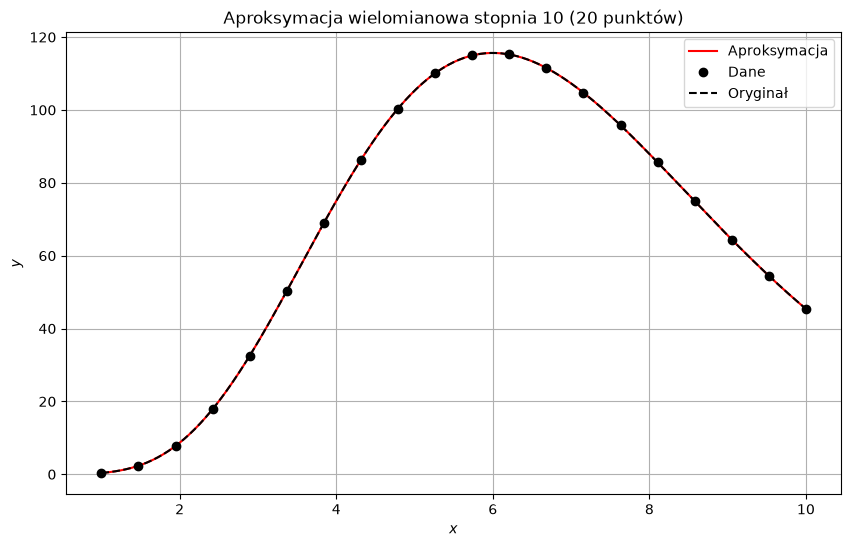

In [6]:
x = np.linspace(min(xx), max(xx), 401)
y = np.polyval(wsp, x)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'r', label='Aproksymacja')
plt.plot(xx, yy, 'ko', label='Dane')
plt.plot(x, fun(x), 'k--', label='Oryginał')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Aproksymacja wielomianowa stopnia {M} ({N} punktów)')
plt.legend()
plt.grid(True)
plt.show()

## Ćwiczenie 1

Zmień $N$ (np. na 10, 50, 100) oraz $M$ (np. 2, 4, 8) i obserwuj:
- Jak zmienia się norma residuów?
- Kiedy metoda 2 (równania normalne) może dać gorsze wyniki numeryczne niż `np.polyfit`?
- Co się dzieje, gdy $M$ zbliża się do $N-1$ (przejście w interpolację)?

> **Podpowiedź:** Dla dużych wartości $M$ macierz $A=F^{\top}F$ stanie się
> słabo określona — sprawdź wyznacznik `np.linalg.det(A)`.

### Podpowiedź — skróty klawiaturowe
| Skróty | Działanie |
|---|---|
| `Ctrl+Enter` | Uruchom komórkę |
| `Shift+Enter` | Uruchom i przejdź do następnej |
| `Shift+Tab` | Tooltip / dokumentacja |
| `Alt+Enter` | Uruchom i wstaw nową komórkę |

## Ćwiczenie 2

Testuj obie metody na funkcji na przedziale $[1, 2]$ (zmień
`np.linspace(1, 10, N)` na `np.linspace(1, 2, N)`). Zwróć uwagę na:
- Różnicę w wartościach współczynników
- Czy norma residuów pozostaje taka sama?

---

> **Uwaga:** NumPy używa SVD w `np.polyfit`, co jest numerycznie
> stabilniejsze niż bezpośrednie rozwiązywanie równań normalnych
> dla danych słabo warunkowanych.